# Raspoznavanje znakova znakovnog jezika

Projekt na predmetu Digitalna obrada i analiza slike

Autori: Lucija Čorak, Mateo Jakšić, Petar Kuruc, Martina Šola, Klara Zagajski

## Postavljanje razvojne okoline

In [2]:
import os
import sys
import urllib
import numpy as np
import pandas as pd
from scipy.stats import *
from scipy.signal import *
import matplotlib.pyplot as plt
from PIL import Image
import skimage
from skimage.color import rgb2gray
from skimage.filters import *
from sklearn.metrics import *
from keras import layers, models
import torch
from torchvision.transforms import ToTensor, ToPILImage, functional
from tqdm import tqdm
from basicsr.archs.rrdbnet_arch import RRDBNet # iz nekog razloga treba dvaput pokrenuti jer prvi put izbaci error

## Učitavanje podataka

Učitamo podatke iz .csv datoteka. Skup podataka se sastoji od 27455 slika u skupu za treniranje i 7172 slika u skupu za testiranje.

In [3]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

Razdvojimo podatke na labele i slike.

In [4]:
X_train = df_train.drop("label", axis=1).values
y_train = df_train["label"].values

X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values

Kreiramo rječnik za labele. Rječnik ne sadržava vrijednosti 9 i 25, jer slova J i Z sadrže geste te nisu prikazani u ovom skupu podataka. Zbog treniranja sve vrijednosti veće od 9 ćemo smanjiti za 1 kako bi olakšali učenje.

In [7]:
label_dict = {
    0: "A",
    1: "B",
    2: "C",
    3: "D",
    4: "E",
    5: "F",
    6: "G",
    7: "H",
    8: "I",
    9: "K",  
    10: "L",
    11: "M",
    12: "N",
    13: "O",
    14: "P",
    15: "Q",
    16: "R",
    17: "S",
    18: "T",
    19: "U",
    20: "V",
    21: "W",
    22: "X",
    23: "Y",
}

y_train[y_train > 9] -= 1
y_test[y_test > 9] -= 1

Kreirati ćemo funkciju za lakše dohvaćanje labela slika.

In [8]:
def get_label(y, index):
    return label_dict[y[index]]

Preoblikujemo slike iz 1D vektora u 2D matrice.

In [9]:
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)

Prikaz primjera slike. Slike su crnobijele i dimenzija 28x28.

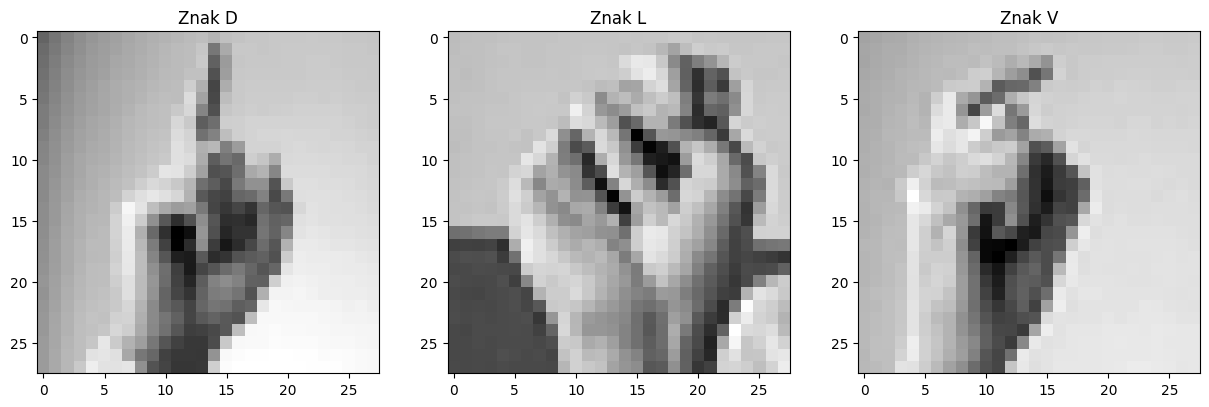

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].imshow(X_train[0], cmap="gray")
axs[0].set_title(f"Znak {get_label(y_train, 0)}")

axs[1].imshow(X_train[1000], cmap="gray")
axs[1].set_title(f"Znak {get_label(y_train, 1000)}")

axs[2].imshow(X_train[10000], cmap="gray")
axs[2].set_title(f"Znak {get_label(y_train, 10000)}");

### Normalizacija

Normaliziramo iz intervala [0, 255] na interval [0, 1].

In [12]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## Model klasifikacije

Kreirati ćemo modele klasifikacije slika znakova znakovnog jezika. Upakirati ćemo ih u funkciju kako bi olakšali daljnje korištenje.

### Konvovlucijska neuronska mreža

In [32]:
def classification_CNN(X_train, y_train, X_test, y_test, epochs_num=5):
    inputs = layers.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, (3, 3), activation="relu")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dense(24, activation="softmax")(x)

    model = models.Model(inputs, x)

    model.compile(optimizer="adam",
                loss="sparse_categorical_crossentropy",
                metrics=["sparse_categorical_accuracy"])

    model.fit(X_train, y_train, epochs=epochs_num, batch_size=32, validation_data=(X_test, y_test))

    y_pred = np.argmax(model.predict(X_test), axis=1)
    print(f"\nKlasifikacijski izvještaj:")
    print(classification_report(y_test, y_pred))

Primjer poziva funkcije klasifikacije konvolucijskom neuronskom mrežom za raspoznavanje znakova znakovnog jezika.

In [26]:
classification_CNN(X_train, y_train, X_test, y_test)

Epoch 1/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 1.7036 - sparse_categorical_accuracy: 0.5075 - val_loss: 0.5001 - val_sparse_categorical_accuracy: 0.8494
Epoch 2/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0661 - sparse_categorical_accuracy: 0.9853 - val_loss: 0.4491 - val_sparse_categorical_accuracy: 0.8829
Epoch 3/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0117 - sparse_categorical_accuracy: 0.9981 - val_loss: 0.4239 - val_sparse_categorical_accuracy: 0.8982
Epoch 4/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0063 - sparse_categorical_accuracy: 0.9987 - val_loss: 0.4761 - val_sparse_categorical_accuracy: 0.9031
Epoch 5/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0026 - sparse_categorical_accuracy: 0.9997 - val_loss: 0.4502 - val_sparse_categorical_accuracy: 0.9161
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Klasifikacijski izvještaj:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       3

### Rezidualna neuronska mreža

In [36]:
def residual_block(x, filters, kernel_size=3, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, kernel_size, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, kernel_size, strides=1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

def classification_resnet(X_train, y_train, X_test, y_test, epochs_num=5):
    inputs = layers.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, 3, strides=1, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 128, stride=2)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(24, activation="softmax")(x)

    model = models.Model(inputs, x)

    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["sparse_categorical_accuracy"])

    model.fit(X_train, y_train, epochs=epochs_num, batch_size=32, validation_data=(X_test, y_test))

    y_pred = np.argmax(model.predict(X_test), axis=1)
    print(f"\nKlasifikacijski izvještaj:")
    print(classification_report(y_test, y_pred))

Primjer poziva funkcije klasifikacije rezidualnom neuronskom mrežom za raspoznavanje znakova znakovnog jezika.

In [72]:
classification_resnet(X_train, y_train, X_test, y_test)

Epoch 1/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 60s 65ms/step - loss: 1.1059 - sparse_categorical_accuracy: 0.7183 - val_loss: 0.2420 - val_sparse_categorical_accuracy: 0.9241
Epoch 2/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 53s 61ms/step - loss: 0.0060 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0484 - val_sparse_categorical_accuracy: 0.9900
Epoch 3/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 50s 58ms/step - loss: 0.0013 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0376 - val_sparse_categorical_accuracy: 0.9926
Epoch 4/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 55s 64ms/step - loss: 0.0010 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0335 - val_sparse_categorical_accuracy: 0.9925
Epoch 5/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 54s 63ms/step - loss: 2.7342e-04 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.0394 - val_sparse_categorical_accuracy: 0.9911
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step

Klasifikacijski izvještaj:
              precision    recall  f1-score   support

           0       1.00      1.00   

## Obrada slika

Isprobat ćemo nekoliko metoda obrade slike s ciljem poboljšanja klasifikacije ili demontracije negativnih efekata na klasifikaciju.

Metode koje planiramo isprobati su: 
- poboljšanje kontrasta (izjednačavanje histograma)
- interpolacija (super rezolucija)

Probali smo još nekoliko metoda, no rezultati su bili iznimno loši jer je skup podataka već obrađen.

Kreiramo funkciju za prikaz originalne i izmjenjene slike.

In [13]:
def prikazi_slike(original, changed, original_naziv, changed_naziv):
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))

    axs[0].imshow(original, cmap="gray")
    axs[0].set_title(original_naziv)
    axs[0].axis("off")
    
    axs[1].imshow(changed, cmap="gray")
    axs[1].set_title(changed_naziv)
    axs[1].axis("off")

### Izjednačavanje histograma

In [33]:
X_train_histogram_equalization = []
for image in X_train:
    cdf, bin_centers = skimage.exposure.cumulative_distribution(image)
    equalized = skimage.img_as_ubyte(np.interp(image, bin_centers, cdf))
    X_train_histogram_equalization.append(equalized)

X_test_histogram_equalization = []
for image in X_test:
    cdf, bin_centers = skimage.exposure.cumulative_distribution(image)
    equalized = skimage.img_as_ubyte(np.interp(image, bin_centers, cdf))
    X_test_histogram_equalization.append(equalized)

X_train_histogram_equalization = np.array(X_train_histogram_equalization)
X_test_histogram_equalization = np.array(X_test_histogram_equalization)

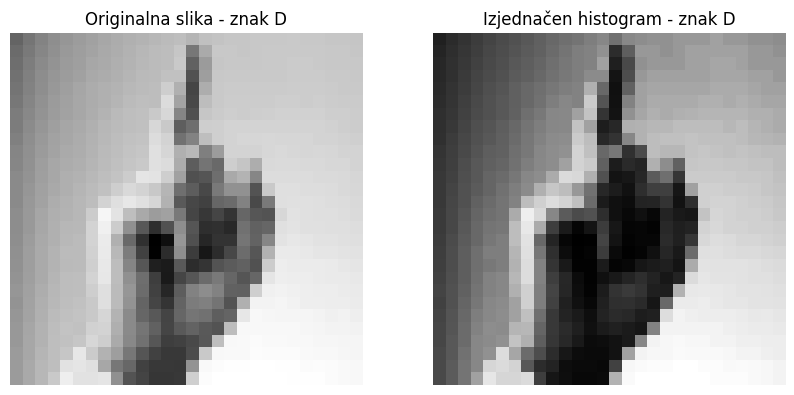

In [34]:
prikazi_slike(X_train[0], X_train_histogram_equalization[0], f"Originalna slika - znak {get_label(y_train, 0)}", f"Izjednačen histogram - znak {get_label(y_train, 0)}")

Testirati ćemo model CNN na skupu slika s izjednačenim histogramom.

In [83]:
classification_CNN(X_train_histogram_equalization, y_train, X_test_histogram_equalization, y_test)

Epoch 1/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 3.1025 - sparse_categorical_accuracy: 0.7179 - val_loss: 0.5914 - val_sparse_categorical_accuracy: 0.8790
Epoch 2/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0513 - sparse_categorical_accuracy: 0.9851 - val_loss: 0.6232 - val_sparse_categorical_accuracy: 0.8928
Epoch 3/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0242 - sparse_categorical_accuracy: 0.9932 - val_loss: 0.5642 - val_sparse_categorical_accuracy: 0.8851
Epoch 4/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0134 - sparse_categorical_accuracy: 0.9960 - val_loss: 1.0653 - val_sparse_categorical_accuracy: 0.8493
Epoch 5/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0323 - sparse_categorical_accuracy: 0.9914 - val_loss: 0.7595 - val_sparse_categorical_accuracy: 0.9018
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Klasifikacijski izvještaj:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       3

Testirati ćemo model ResNet na skupu slika s izjednačenim histogramom.

In [84]:
classification_resnet(X_train_histogram_equalization, y_train, X_test_histogram_equalization, y_test)

Epoch 1/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 55s 59ms/step - loss: 0.9150 - sparse_categorical_accuracy: 0.7753 - val_loss: 0.4221 - val_sparse_categorical_accuracy: 0.8766
Epoch 2/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 54s 63ms/step - loss: 0.0223 - sparse_categorical_accuracy: 0.9974 - val_loss: 0.1320 - val_sparse_categorical_accuracy: 0.9573
Epoch 3/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 50s 58ms/step - loss: 0.0011 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.1341 - val_sparse_categorical_accuracy: 0.9523
Epoch 4/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 53s 62ms/step - loss: 4.2053e-04 - sparse_categorical_accuracy: 1.0000 - val_loss: 0.1303 - val_sparse_categorical_accuracy: 0.9561
Epoch 5/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 52s 61ms/step - loss: 0.0706 - sparse_categorical_accuracy: 0.9815 - val_loss: 0.0980 - val_sparse_categorical_accuracy: 0.9663
225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step

Klasifikacijski izvještaj:
              precision    recall  f1-score   support

           0       1.00      1.00   

### Interpolacija

Cilj interpolacije je povećanje dimenzionalnosti slike. Radimo sa slikama niske rezolucije (28x28), to može predstavljati problem prilikom treniranje modela klasifikacije zbog nedostatka detalja i oštrine. 

Isprobati ćemo ESRGAN (Enhanced Super Resolution Generative Adversarial Networks). To je duboki unaprijed trenirani model neuronske mreže koji služi za pametno povećanje rezolucije slika.

#### ESRGAN (Enhanced Super Resolution Generative Adversarial Networks)

Modeli korišteni u nastavku projekta su preuzeti s https://huggingface.co/ai-forever/Real-ESRGAN/tree/main.

In [13]:
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [15]:
def super_resolve_x2(model, image):
    with torch.no_grad():
        img = image.astype(np.float32)

        if img.ndim == 2:
            img = np.expand_dims(img, axis=2)
        if img.shape[2] == 1:
            img = np.repeat(img, 3, axis=2)

        img = np.tile(img, (1, 1, 4))
        img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)

        output = model(img)
        output = output.squeeze(0)
        output = output.clamp(0, 1)
        output = output.permute(1, 2, 0).numpy()

        return output

Super-resolving X_test: 100%|██████████| 7172/7172 [20:54<00:00,  5.72it/s]


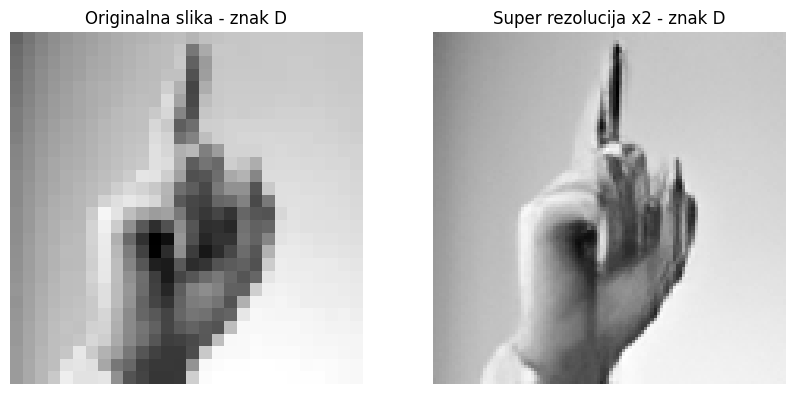

In [198]:
input_path = "models/RealESRGAN_x2.pth"

model = RRDBNet(num_in_ch=12, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32)

state_dict = torch.load(input_path, map_location="cpu")
model.load_state_dict(state_dict, strict=False)
model.eval()

prikazi_slike(X_train[0], rgb2gray(super_resolve_x2(model, X_train[0])), 
              f"Originalna slika - znak {get_label(y_train, 0)}", f"Super rezolucija x2 - znak {get_label(y_train, 0)}")

X_train_sr_x2 = []
for image in tqdm(X_train, desc="Super-resolving X_train"):
    sr_image = super_resolve_x2(model, image)
    X_train_sr_x2.append((rgb2gray(sr_image) * 255).astype(np.uint8))

X_test_sr_x2 = []
for image in tqdm(X_test, desc="Super-resolving X_test"):
    sr_image = super_resolve_x2(model, image)
    X_test_sr_x2.append((rgb2gray(sr_image) * 255).astype(np.uint8))

X_train_sr_x2 = np.array(X_train_sr_x2)
X_test_sr_x2 = np.array(X_test_sr_x2)

In [16]:
def super_resolve_x4(model, image):
    with torch.no_grad():
        img = image.astype(np.float32)

        if img.ndim == 2:
            img = np.expand_dims(img, axis=2)
        if img.shape[2] == 1:
            img = np.repeat(img, 3, axis=2)

        img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)

        output = model(img)
        output = output.squeeze(0)
        output = output.clamp(0, 1)
        output = output.permute(1, 2, 0).numpy()

        return output

Super-resolving X_test: 100%|██████████| 7172/7172 [20:22<00:00,  5.87it/s]


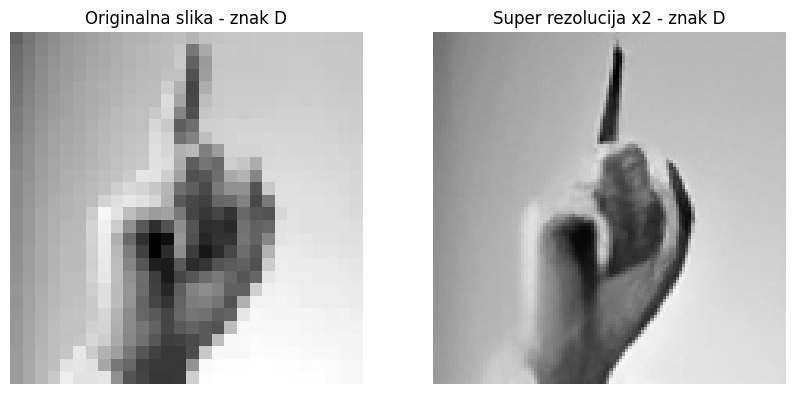

In [200]:
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

input_path = "models/RealESRGAN_x4.pth"

model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32)

state_dict = torch.load(input_path, map_location="cpu")
model.load_state_dict(state_dict, strict=False)
model.eval()

prikazi_slike(X_train[0], rgb2gray(super_resolve_x4(model, X_train[0])), 
              f"Originalna slika - znak {get_label(y_train, 0)}", f"Super rezolucija x2 - znak {get_label(y_train, 0)}")

X_train_sr_x4 = []
for image in tqdm(X_train, desc="Super-resolving X_train"):
    sr_image = super_resolve_x4(model, image)
    X_train_sr_x4.append(rgb2gray(sr_image))

X_test_sr_x4 = []
for image in tqdm(X_test, desc="Super-resolving X_test"):
    sr_image = super_resolve_x4(model, image)
    X_test_sr_x4.append(rgb2gray(sr_image))

X_train_sr_x4 = np.array(X_train_sr_x4)
X_test_sr_x4 = np.array(X_test_sr_x4)

### Testiranje klasifikacije na interpoliranim slikama

Prvo moramo prilagoditi neuronske mreže na slike dimenzija 112x112.

### Konvolucijska neuronska mreža

In [34]:
def classification_CNN_112(X_train, y_train, X_test, y_test, epochs_num=10):
    inputs = layers.Input(shape=(112, 112, 1))

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(24, activation="softmax")(x)

    model = models.Model(inputs, x)

    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["sparse_categorical_accuracy"])

    model.fit(X_train, y_train, epochs=epochs_num, batch_size=32, validation_data=(X_test, y_test))

    y_pred = np.argmax(model.predict(X_test), axis=1)
    print(f"\nKlasifikacijski izvještaj:")
    print(classification_report(y_test, y_pred))


### Rezidualna neuronska mreža

In [18]:
def residual_block_112(x, filters, kernel_size=3, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, kernel_size, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, kernel_size, strides=1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or x.shape[-1] != shortcut.shape[-1]:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

def classification_resnet_112(X_train, y_train, X_test, y_test, epochs_num=5):
    inputs = layers.Input(shape=(112, 112, 1))

    x = layers.Conv2D(32, 3, strides=1, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block_112(x, 32)
    x = residual_block_112(x, 32)

    x = residual_block_112(x, 64, stride=2)
    x = residual_block_112(x, 64)

    x = residual_block_112(x, 128, stride=2)
    x = residual_block_112(x, 128)

    x = residual_block_112(x, 256, stride=2)
    x = residual_block_112(x, 256)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(24, activation="softmax")(x)

    model = models.Model(inputs, x)

    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["sparse_categorical_accuracy"])

    model.fit(X_train, y_train, epochs=epochs_num, batch_size=32, validation_data=(X_test, y_test))

    y_pred = np.argmax(model.predict(X_test), axis=1)
    print(f"\nKlasifikacijski izvještaj:")
    print(classification_report(y_test, y_pred))


### Super rezolucija x2

In [35]:
classification_CNN_112(X_train_sr_x2, y_train_sr_x2, X_test_sr_x2, y_test_sr_x2)

Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 140s 162ms/step - loss: 3.0807 - sparse_categorical_accuracy: 0.4590 - val_loss: 0.3457 - val_sparse_categorical_accuracy: 0.9264
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 135s 157ms/step - loss: 0.1135 - sparse_categorical_accuracy: 0.9613 - val_loss: 0.3949 - val_sparse_categorical_accuracy: 0.9223
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 132s 154ms/step - loss: 0.0636 - sparse_categorical_accuracy: 0.9791 - val_loss: 0.4473 - val_sparse_categorical_accuracy: 0.9122
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 135s 157ms/step - loss: 0.0530 - sparse_categorical_accuracy: 0.9838 - val_loss: 0.4398 - val_sparse_categorical_accuracy: 0.9278
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 137s 160ms/step - loss: 0.0563 - sparse_categorical_accuracy: 0.9834 - val_loss: 0.4347 - val_sparse_categorical_accuracy: 0.9279
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 137s 160ms/step - loss: 0.0496 - sparse_categorical_accuracy: 0.9861 - val_loss: 0.4636 - val_sparse_categoric

In [41]:
classification_resnet_112(X_train_sr_x2, y_train_sr_x2, X_test_sr_x2, y_test_sr_x2)

Epoch 1/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 1443s 2s/step - loss: 1.9031 - sparse_categorical_accuracy: 0.4307 - val_loss: 6.2234 - val_sparse_categorical_accuracy: 0.1477
Epoch 2/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 1395s 2s/step - loss: 0.0740 - sparse_categorical_accuracy: 0.9836 - val_loss: 0.0172 - val_sparse_categorical_accuracy: 0.9983
Epoch 3/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 1419s 2s/step - loss: 0.0110 - sparse_categorical_accuracy: 0.9979 - val_loss: 0.0161 - val_sparse_categorical_accuracy: 0.9946
Epoch 4/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 1410s 2s/step - loss: 0.0105 - sparse_categorical_accuracy: 0.9981 - val_loss: 0.0383 - val_sparse_categorical_accuracy: 0.9933
Epoch 5/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 1486s 2s/step - loss: 0.0021 - sparse_categorical_accuracy: 0.9999 - val_loss: 0.0081 - val_sparse_categorical_accuracy: 0.9990
225/225 ━━━━━━━━━━━━━━━━━━━━ 87s 383ms/step

Klasifikacijski izvještaj:
              precision    recall  f1-score   support

           0       1.00      1.00     

### Super rezolucija x4

In [42]:
classification_CNN_112(X_train_sr_x4, y_train_sr_x4, X_test_sr_x4, y_test_sr_x4)

Epoch 1/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 139s 159ms/step - loss: 2.1562 - sparse_categorical_accuracy: 0.5593 - val_loss: 0.2360 - val_sparse_categorical_accuracy: 0.9324
Epoch 2/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 122s 142ms/step - loss: 0.1022 - sparse_categorical_accuracy: 0.9672 - val_loss: 0.1733 - val_sparse_categorical_accuracy: 0.9518
Epoch 3/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 119s 138ms/step - loss: 0.0597 - sparse_categorical_accuracy: 0.9806 - val_loss: 0.2313 - val_sparse_categorical_accuracy: 0.9488
Epoch 4/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 113s 132ms/step - loss: 0.0529 - sparse_categorical_accuracy: 0.9838 - val_loss: 0.2749 - val_sparse_categorical_accuracy: 0.9433
Epoch 5/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 120s 140ms/step - loss: 0.0425 - sparse_categorical_accuracy: 0.9874 - val_loss: 0.2715 - val_sparse_categorical_accuracy: 0.9480
Epoch 6/10
858/858 ━━━━━━━━━━━━━━━━━━━━ 112s 131ms/step - loss: 0.0245 - sparse_categorical_accuracy: 0.9925 - val_loss: 0.2669 - val_sparse_categoric

In [20]:
classification_resnet_112(X_train_sr_x4, y_train_sr_x4, X_test_sr_x4, y_test_sr_x4)

Epoch 1/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 1683s 2s/step - loss: 1.5507 - sparse_categorical_accuracy: 0.5415 - val_loss: 0.2423 - val_sparse_categorical_accuracy: 0.9225
Epoch 2/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 1620s 2s/step - loss: 0.0476 - sparse_categorical_accuracy: 0.9922 - val_loss: 0.0221 - val_sparse_categorical_accuracy: 0.9939
Epoch 3/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 1663s 2s/step - loss: 0.0151 - sparse_categorical_accuracy: 0.9965 - val_loss: 0.0257 - val_sparse_categorical_accuracy: 0.9916
Epoch 4/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 1620s 2s/step - loss: 0.0125 - sparse_categorical_accuracy: 0.9975 - val_loss: 0.0074 - val_sparse_categorical_accuracy: 0.9972
Epoch 5/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 1639s 2s/step - loss: 0.0014 - sparse_categorical_accuracy: 1.0000 - val_loss: 9.4183e-04 - val_sparse_categorical_accuracy: 0.9999
225/225 ━━━━━━━━━━━━━━━━━━━━ 73s 322ms/step

Klasifikacijski izvještaj:
              precision    recall  f1-score   support

           0       1.00      1.00 

### Spremanje i dohvaćanje slika dobivenih super rezolucijom

Izvođenje super rezolucije traje više od 1h. Implementirano je spremanje i učitavanje slika, kako bi se uštedilo vrijeme.

In [15]:
def save_as_csv(images, labels, filename):
    data_rows = []
    for img, label in zip(images, labels):
        img = img.flatten()
        img = 255 - (img * 255.0).astype(np.uint8)
        row = [label] + img.tolist()
        data_rows.append(row)

    pixel_columns = [f"pixel{i+1}" for i in range(len(data_rows[0]) - 1)]
    columns = ["label"] + pixel_columns
    df = pd.DataFrame(data_rows, columns=columns)
    df.to_csv(filename, index=False)

def load_data(filename):
    df = pd.read_csv(filename)
    y = df["label"].values
    X = df.drop("label", axis=1).values
    X = X.reshape(-1, 112, 112)
    return X, y

In [ ]:
save_as_csv(X_train_sr_x2, y_train, "data/X_train_sr_x2.csv")
save_as_csv(X_test_sr_x2, y_test, "data/X_test_sr_x2.csv")
save_as_csv(X_train_sr_x4, y_train, "data/X_train_sr_x4.csv")
save_as_csv(X_test_sr_x4, y_test, "data/X_test_sr_x4.csv")

In [16]:
X_train_sr_x2, y_train_sr_x2 = load_data("data/X_train_sr_x2.csv")
X_test_sr_x2, y_test_sr_x2 = load_data("data/X_test_sr_x2.csv")
X_train_sr_x4, y_train_sr_x4 = load_data("data/X_train_sr_x4.csv")
X_test_sr_x4, y_test_sr_x4 = load_data("data/X_test_sr_x4.csv")

Usporedni prikaz x2 i x4 super rezolucije.

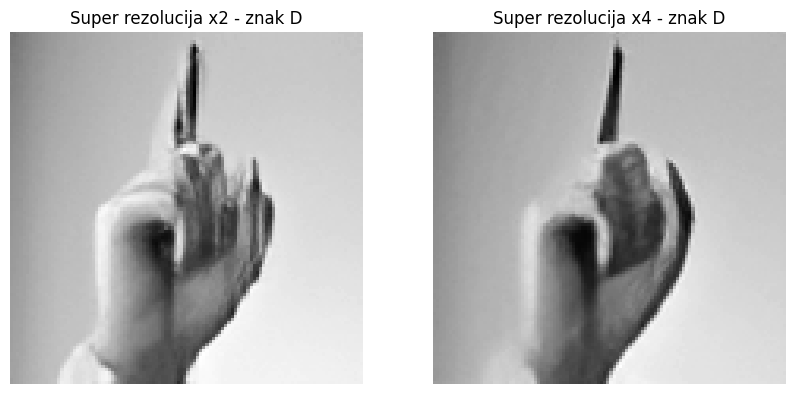

In [20]:
prikazi_slike(X_train_sr_x2[0], 255 - X_train_sr_x4[0], f"Super rezolucija x2 - znak {get_label(y_train_sr_x2, 0)}", f"Super rezolucija x4 - znak {get_label(y_train_sr_x4, 0)}") 